In [1]:
import jax
import jax.numpy as jnp
import tqdm
import blackjax

from jax import jit

import jax.numpy as jnp
from jax import jit
from ceridwen.ssps.ssp_data import SSPData, collect_ssp_data_wrapper
from ceridwen.csp.csp import CSPBasis
import astropy.constants as const

import matplotlib.pyplot as plt
import fsps

jax.config.update("jax_enable_x64", True)
#disable hit


In [ ]:
ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

csp = CSPBasis(ssp_data)
tuniv = 13.8
num_time_bins = 3
gal_t_table = jnp.linspace(0.1, 13.78, num_time_bins)
gal_sfr_table = jnp.linspace(0.1, 10, len(gal_t_table))
gal_z_table = jnp.ones_like(gal_sfr_table)*csp.zlegend[3] #jnp.array([4.49043431e-05, 1.42000001e-04, 2.52515678e-04, 4.49043431e-04,
       #7.98524687e-04, 1.42000001e-03, 2.52515678e-03, 4.49043431e-03,
       #7.98524687e-03, 1.42000001e-02, 1.42000001e-02, 1.42000001e-02])

csp.add_sfh(sfh=gal_sfr_table, lookback_time=13.8 - gal_t_table)
csp.add_zh(zh=gal_z_table, lookback_time=13.8 - gal_t_table)
spectrum1 = csp.get_spectrum()


lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


In [3]:
rng_key = jax.random.PRNGKey(0)
num_dims = len(gal_sfr_table) + len(gal_z_table) 
num_live = 1000
num_inner_steps = num_dims * 5
num_delete = num_live // 2

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


(1e-05, 0.0001)

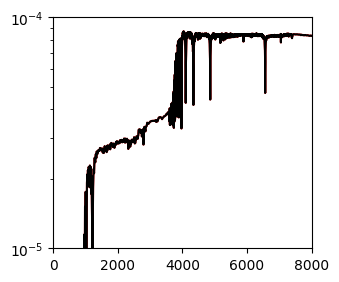

In [4]:

gal_t_table = jnp.linspace(0.1, 13.78, num_time_bins)

# True parameters
true_sfh = jnp.linspace(0.1, 10, num_time_bins)
true_zh = jnp.ones_like(true_sfh) * csp.zlegend[0]

# Create "true" spectrum
csp_true = CSPBasis(ssp_data)
csp_true.add_sfh(sfh=true_sfh, lookback_time=13.8 - gal_t_table)
csp_true.add_zh(zh=true_zh, lookback_time=13.8 - gal_t_table)
spectrum_clean = csp_true.get_spectrum()

# Add noise
key, rng_key = jax.random.split(rng_key)
sigma = 0.003 * jnp.max(spectrum_clean)  # relative noise level
noise = sigma * jax.random.normal(key, shape=spectrum_clean.shape)
spectrum_obs = spectrum_clean #+ noise

plt.figure(figsize=(10/3, 3))
plt.plot(csp_true.wave, spectrum_obs, label='Observed Spectrum', color='red')
plt.plot(csp_true.wave, csp_true.spectrum, label='CSP Spectrum', color='black')
#plt.errorbar(csp_true.wave, spectrum_obs, yerr=jnp.abs(noise), label='Clean Spectrum', color='blue')
plt.xlim(0, 8000)
plt.yscale('log')
plt.ylim(1e-5, 1e-4)

In [5]:
from functools import partial
from jax import jit, grad

csp = CSPBasis(ssp_data)

sfh = jnp.ones_like(gal_t_table)  # Initial guess for SFH
zh = jnp.ones_like(gal_t_table) * csp.zlegend[2]
csp.add_sfh(sfh=sfh, lookback_time=13.8 - gal_t_table) #need to set sfh_times 
model = partial(csp.get_spectrum_direct)  # csp is now static

# JIT works
model = jax.jit(model)
spectrum = model(sfh, zh)

# grad also works (with respect to sfh, for example)
grad_spectrum = grad(lambda sfh: jnp.sum(model(sfh, zh)))(sfh)

lookback time


Test 0: NaNs in spectrum? False | Min=8.95164367533207e-12, Max=0.00014397377403430235
Test 1: NaNs in spectrum? False | Min=8.759523855378959e-12, Max=0.0001182557305279557
Test 2: NaNs in spectrum? False | Min=4.9791909624185935e-12, Max=6.993923035880406e-05
Test 3: NaNs in spectrum? False | Min=1.0548091694042445e-12, Max=3.571625442505463e-05
Test 4: NaNs in spectrum? False | Min=7.237466980020489e-12, Max=8.654471487457616e-05


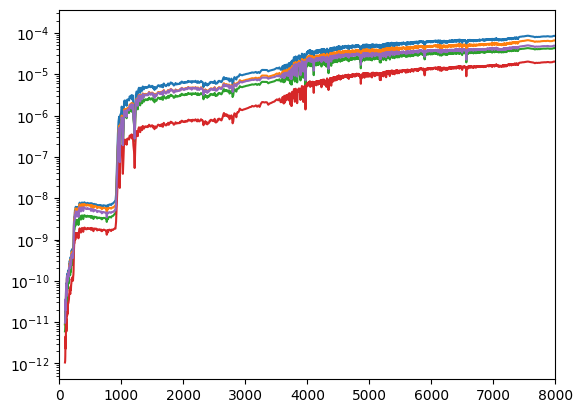

In [6]:
def validate_model(model, rng_key, n=5):
    for i in range(n):
        rng_key, key1, key2 = jax.random.split(rng_key, 3)
        sfh = jax.random.uniform(key1, shape=(3,), minval=0.1, maxval=10.0)
        zh = jax.random.uniform(key2, shape=(3,), minval=1e-5, maxval=0.03)
        spec = model(sfh, zh)
        plt.plot(csp.wave, spec)
        print(f"Test {i}: NaNs in spectrum? {jnp.any(jnp.isnan(spec))} | Min={jnp.min(spec)}, Max={jnp.max(spec)}")
plt.xlim(0, 8000)
plt.yscale('log')
validate_model(model, rng_key)

(1e-07, 0.0001)

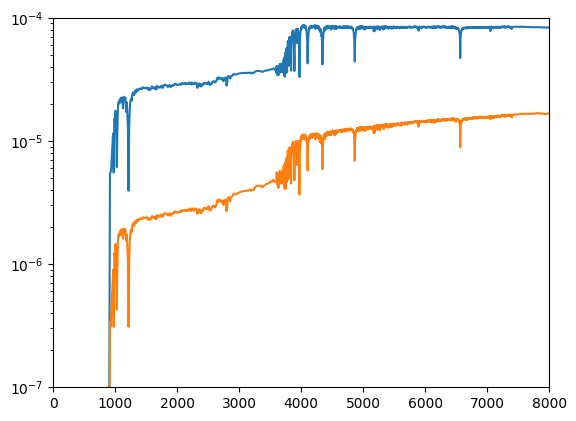

In [7]:
plt.plot(csp.wave, model(true_sfh, true_zh))
plt.plot(csp.wave, model(sfh, zh))
plt.xlim(0, 8000)
plt.yscale('log')
plt.ylim(1e-7, 1e-4)

In [8]:
n_bins = len(gal_t_table)
print(n_bins)
prior_bounds = {
    "sigma": (1e-7, 1e-5)
}
for i in range(n_bins):
    prior_bounds[f"sfh_{i}"] = (0.1, 20.0)
    prior_bounds[f"zh_{i}"] = (6e-5, 0.03)


2


# Likelihood Function

In [9]:
def unpack_params(params_flat, n_bins):
    sfh = jnp.array([params_flat[f"sfh_{i}"] for i in range(n_bins)])
    zh  = jnp.array([params_flat[f"zh_{i}"]  for i in range(n_bins)])
    sigma = jnp.array(params_flat["sigma"])
    return sfh, zh, sigma

@jit
def loglikelihood_fn(params_flat):
    sfh, zh, sigma = unpack_params(params_flat, n_bins)

    mu = model(sfh, zh)
    cov = sigma ** 2
    lgl = jax.scipy.stats.multivariate_normal.logpdf(spectrum_obs, mu, cov)
    return lgl

from blackjax.ns.utils import uniform_prior

rng_key, prior_key = jax.random.split(rng_key)
particles, logprior_fn = uniform_prior(prior_key, num_live, prior_bounds)

# How fast is the likelihood function?

In [10]:
prior_bounds = {
    'sfh_0': (0.001, 12.0),
    'sfh_1': (0.001, 12.0),
    'sfh_2': (0.001, 12.0),
    'zh_0': (5e-5, 0.02),
    'zh_1': (5e-5, 0.02),
    'zh_2': (5e-5, 0.02),
    'sigma': (1e-7, 1e-5),
}

In [11]:
def generate_param_dict_from_bounds(bounds: dict, num_particles: int, key):
    keys = jax.random.split(key, len(bounds))
    params = {
        k: jax.random.uniform(
            keys[i], shape=(num_particles,),
            minval=bounds[k][0], maxval=bounds[k][1]
        )
        for i, k in enumerate(bounds)
    }
    return params

In [17]:
params_test = {'sfh_0': jnp.array([6.89615003, 3]),
 'sfh_1': jnp.array([2.78799016, 4]),
 'sfh_2': jnp.array([2.02322524, 5]),
 'sigma': jnp.array([0.0059143, 0.001]),
 'zh_0': jnp.array([0.00010885, 0.00044]),
 'zh_1': jnp.array([0.0002968, 0.0008]),
 'zh_2': jnp.array([0.0001728, 0.0009])}

lls = jax.vmap(loglikelihood_fn)(params_test)

In [15]:
# Compile batched version
batched_loglikelihood = jax.vmap(jax.jit(loglikelihood_fn))

In [ ]:
import time

# Particle sizes to test
N_values = [1, 10, 100, 1000, 5000, 10000, 20000, 50000]
timings = []
rng_key = jax.random.PRNGKey(42)

# Run benchmark
for N in N_values:
    rng_key, subkey = jax.random.split(rng_key)
    print(f"\nGenerating {N} particles...")
    params = generate_param_dict_from_bounds(prior_bounds, N, subkey)
    print(f"Evaluating log-likelihood for {N} particles...")
    
    # Warm-up
    _ = batched_loglikelihood(params).block_until_ready()
    
    # Time the evaluation
    t0 = time.time()
    _ = batched_loglikelihood(params).block_until_ready()
    t1 = time.time()
    
    timings.append(t1 - t0)
    print(f"{N:>6} particles: {t1 - t0:.4f} seconds")




Generating 1 particles...
Evaluating log-likelihood for 1 particles...
     1 particles: 0.0150 seconds

Generating 10 particles...
Evaluating log-likelihood for 10 particles...
    10 particles: 0.1171 seconds

Generating 100 particles...
Evaluating log-likelihood for 100 particles...
   100 particles: 0.7092 seconds

Generating 1000 particles...
Evaluating log-likelihood for 1000 particles...
  1000 particles: 20.2270 seconds

Generating 5000 particles...
Evaluating log-likelihood for 5000 particles...


KeyboardInterrupt: 

: 

In [ ]:
import time

for N in [1, 10, 100, 500, 1000, 10000, 100000]:
    rng_key, subkey = jax.random.split(rng_key)
    params_test = generate_param_dict_from_bounds(prior_bounds, N, subkey)

    # Warm-up
    _ = jax.vmap(loglikelihood_fn)(params_test).block_until_ready()

    # Timed run
    t0 = time.time()
    lls = jax.vmap(loglikelihood_fn)(params_test).block_until_ready()
    t1 = time.time()

    print(f"N = {N:>6}, time = {t1 - t0:.4f} s")

N =      1, time = 0.0193 s
N =     10, time = 0.2114 s
N =    100, time = 1.7293 s
N =   1000, time = 38.4968 s


KeyboardInterrupt: 

: 

In [13]:
import time

In [14]:
# Compile batched version
batched_loglikelihood = jax.jit(jax.vmap(loglikelihood_fn))

# Particle sizes to test
N_values = [1, 10, 100, 1000, 5000, 10000, 20000, 50000]
timings = []
rng_key = jax.random.PRNGKey(42)

# Run benchmark
for N in N_values:
    rng_key, subkey = jax.random.split(rng_key)
    params = generate_param_dict_from_bounds(prior_bounds, N, subkey)
    print(f"Evaluating log-likelihood for {N} particles...")
    
    # Warm-up
    _ = batched_loglikelihood(params).block_until_ready()
    
    # Time the evaluation
    t0 = time.time()
    _ = batched_loglikelihood(params).block_until_ready()
    t1 = time.time()
    
    timings.append(t1 - t0)
    print(f"{N:>6} particles: {t1 - t0:.4f} seconds")



Evaluating log-likelihood for 1 particles...
     1 particles: 0.0197 seconds
Evaluating log-likelihood for 10 particles...
    10 particles: 0.2215 seconds
Evaluating log-likelihood for 100 particles...
   100 particles: 1.1001 seconds
Evaluating log-likelihood for 1000 particles...
  1000 particles: 32.8022 seconds
Evaluating log-likelihood for 5000 particles...


: 

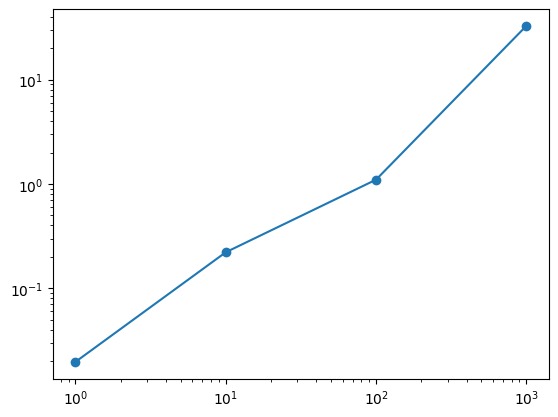

In [13]:
n = [1, 10, 100, 1000]
t = [0.0197, 0.2215, 1.1001, 32.8022]

plt.loglog(n, t, marker='o')

In [ ]:
# Plot results
plt.figure(figsize=(8, 5))
plt.plot(N_values, timings, marker='o')
plt.xlabel("Number of particles")
plt.ylabel("Log-likelihood evaluation time [s]")
plt.title("Scaling of log-likelihood evaluation with particle number")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
params_test = {'sfh_0': jnp.array([6.89615003, 3]),
 'sfh_1': jnp.array([2.78799016, 4]),
 'sfh_2': jnp.array([2.02322524, 5]),
 'sigma': jnp.array([0.0059143, 0.001]),
 'zh_0': jnp.array([0.00010885, 0.00044]),
 'zh_1': jnp.array([0.0002968, 0.0008]),
 'zh_2': jnp.array([0.0001728, 0.0009])}


lls = jax.vmap(loglikelihood_fn)(params_test)

In [10]:
params_list = [{k: v[i] for k, v in particles.items()} for i in range(num_live)]
lls = jnp.array([loglikelihood_fn(p) for p in params_list])

print("Valid log-likelihoods:", jnp.sum(jnp.isfinite(lls)))
print("Min:", jnp.min(lls))
print("Max:", jnp.max(lls))

Valid log-likelihoods: 1000
Min: -2663385472.6397486
Max: 49733.79287380218


In [11]:
from jax.scipy.stats import multivariate_normal

mu = model(true_sfh, true_zh)
mu2 = model(sfh, zh)
sigma = 1e-7
logpdf = multivariate_normal.logpdf(spectrum_obs, mu, sigma**2)
logpdf2 = multivariate_normal.logpdf(spectrum_obs, mu2, sigma**2)

print("logpdf at true params:", logpdf)
print("logpdf at guess:", logpdf2)
print("Δ log-likelihood:", logpdf - logpdf2)

logpdf at true params: 91103.74776381537
logpdf at guess: -1020325033.2976078
Δ log-likelihood: 1020416137.0453717


In [12]:
print("mu_true min/max:", jnp.min(mu), jnp.max(mu))
print("spectrum_obs min/max:", jnp.min(spectrum_obs), jnp.max(spectrum_obs))

mu_true min/max: -2.820230458166881e-17 8.697928164005294e-05
spectrum_obs min/max: -2.820230794214712e-17 8.697928164005265e-05


In [13]:
print("mu_true:  min =", jnp.min(mu), ", max =", jnp.max(mu))
print("mu_guess: min =", jnp.min(mu2), ", max =", jnp.max(mu2))
print("spectrum_obs: min =", jnp.min(spectrum_obs), ", max =", jnp.max(spectrum_obs))
print("sigma =", sigma)

mu_true:  min = -2.820230458166881e-17 , max = 8.697928164005294e-05
mu_guess: min = 7.694654616737701e-13 , max = 1.759325033498852e-05
spectrum_obs: min = -2.820230794214712e-17 , max = 8.697928164005265e-05
sigma = 1e-07


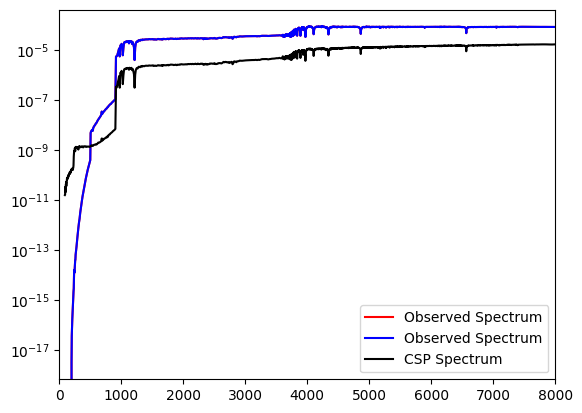

In [14]:
plt.plot(csp.wave, mu, label='Observed Spectrum', color='red')
plt.plot(csp.wave, spectrum_obs, label='Observed Spectrum', color='blue')
plt.plot(csp.wave, mu2, label='CSP Spectrum', color='black')
plt.xlim(0, 8000)
plt.yscale('log')
plt.legend()

In [15]:
param_test = {
    "sfh_0": 10.0,
    "sfh_1": 0.7,
    #"sfh_2": 2.80,
    "zh_0": 1e-4,
    "zh_1": 1e-4,
    #"zh_2": 1e-4,
    "sigma": 1e-5
}
import time

start = time.time()
loglikelihood_fn(param_test)
print("Time per loglikelihood:", time.time() - start)

Time per loglikelihood: 0.5057616233825684


In [ ]:
vmap the whole thing for parlalised processes

In [16]:
start = time.time()
l = loglikelihood_fn(param_test)
print("Time per loglikelihood:", time.time() - start, 'l', l)

Time per loglikelihood: 0.0005488395690917969 l 32089.94378087541


# Sampling

In [17]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
)
init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)

live = init_fn(particles)

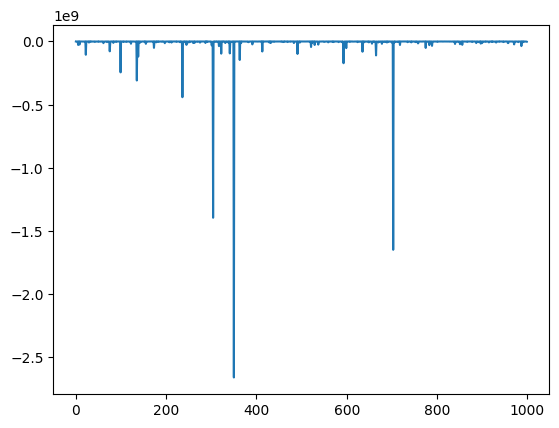

In [18]:
plt.plot(live.loglikelihood)

In [18]:
sum(jnp.isnan(live.logprior))

Array(0, dtype=int64, weak_type=True)

In [19]:
live.logprior

Array([12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55865614,
       12.55865614, 12.55865614, 12.55865614, 12.55865614, 12.55

In [20]:
dead = []

rng_key, subkey = jax.random.split(rng_key, 2)
#with jax.disable_jit():
live, dead_info = step_fn(subkey, live)
dead.append(dead_info)


In [ ]:
dead

In [ ]:

dead = []
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.logZ_live - live.logZ < -3:
        print(f"Current logZ: {live.logZ_live - live.logZ}")
        rng_key, subkey = jax.random.split(rng_key, 2)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_delete)

dead = blackjax.ns.utils.finalise(live, dead)

Dead points: 0 dead points [00:00, ? dead points/s]

Current logZ: nan


Dead points: 500 dead points [00:59, 11.81 dead points/s]

#STOP

In [18]:
from blackjax.ns.base import NSInfo
print(f"{NSInfo.__doc__}")



Additional information returned at each step of the Nested Sampling algorithm.

    Attributes
    ----------
    particles
        The PyTree of particles that were marked as "dead" (replaced) in the
        current step.
    loglikelihood
        The log-likelihood values of the dead particles.
    loglikelihood_birth
        The birth log-likelihood thresholds of the dead particles.
    logprior
        The log-prior values of the dead particles.
    inner_kernel_info
        A NamedTuple (or any PyTree) containing information from the update step
        (inner kernel) used to generate new live particles. The content
        depends on the specific inner kernel used.
    


In [ ]:

def one_step(carry, xs):
    state, k = carry
    k, subk = jax.random.split(k, 2)
    state, dead_point = nested_sampler.step(subk, state)
    return (state, k), dead_point

init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)

state = init_fn(particles)

In [ ]:
dead = []

with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not state.logZ_live - state.logZ < -3:
        (state, rng_key), dead_info = one_step((state, rng_key), None)
        dead.append(dead_info)
        pbar.update(num_delete)

Dead points: 500 dead points [01:20,  6.19 dead points/s]